In [177]:

import numpy as np
from itertools import product
import numpy as np
from math import comb, lgamma, gamma
import matplotlib.pyplot as plt
#import sympy as sp
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh



def C(m1,m2,M,l):
    if(m1+m2==M+l):
        # print(np.sqrt((2**(m1+m2))))
        ll=lgamma(m1+1)+lgamma(m2+1)-lgamma(M+1)-lgamma(l+1)
        A = 1.0/ np.sqrt((2**(m1+m2) * np.exp(ll)))
        # print(m1,m2,A)
        sum_ = 0
        for k in range(max(0,l-m2),min(l,m1)+1):
            # for fermions we have two coeff substracted
            sum_+= comb(m1,k)*comb(m2,l-k)*(-1)**(l-k)
        return A*sum_
    else:
        return 0

def vcolumb(l):
    return gamma(l+1/2)/gamma(l+1)

def vhardcore(l):
    if l==1:
        return 1
    else:
        return 0

def V_2(v_l,m1_prime,m2_prime,m1,m2):
    """Returns the matrix elements of two particles for a pseudopotential v_l upto an angular momentum L"""
    
    # fermionic_basis_sorted_upto_L = create_fermionic_basis(L)
    sum_= 0
    if(m1+m2 == m1_prime+m2_prime):
        for l in range(m1+m2+1):
            M = m1+m2-l
            # since M+l=L therefore M = L-l
            fermionic_term = C(m1_prime,m2_prime,M,l)*C(m1,m2,M,l)- C(m1_prime,m2_prime,M,l)*C(m2,m1,M,l)- C(m2_prime,m1_prime,M,l)*C(m1,m2,M,l)+ C(m2_prime,m1_prime,M,l)*C(m2,m1,M,l)
            sum_+= fermionic_term*v_l(l)/(2)

    return sum_


def compareLists(a,b):
    for i,j in zip(a,b):
        if i>j:
            return 1
        elif i<j:
            return -1
    return 0

In [178]:
([1,2,10],[1,2,4])

([1, 2, 10], [1, 2, 4])

In [179]:
def sortListOfLists(l):
    return sorted(l, key=lambda x: x)


def searchSortedList(l, item):
    low = 0
    high = len(l) - 1

    while low <= high:
        mid = (low + high) // 2
        comparison = compareLists(l[mid], item)

        if comparison == 0:
            return mid  # Item found at index mid
        elif comparison < 0:
            low = mid + 1  # Search in the upper half
        else:
            high = mid - 1  # Search in the lower half
            
    return -1  # Item not found

In [166]:

def create_fermionic_basis(n,L):
    """Returns a fermionic basis for n particles upto a total angular momentum L"""
    # Note that the constraint m_1<L and m_2<L has been used not m_1+m_2<L 
    # n= number of particles:
    # L= total angular momentum

    a = [i for i in range(0,L+1)]
    # take cartesian product to produce all possibilities of states for whole hilbert space
    res = list(product(a, repeat=n))
    # print(res)
    no_dup_basis = []
    for i in range(len(res)):
        # print(res[i])
        # print(f"after set: {set(res[i])}")7890-

        # set returns list after removing duplicates
        if(len(res[i])==len(set(res[i]))):
            no_dup_basis.append(res[i])
    

    L_values = [sum(l) for l in no_dup_basis]
    sorted_indices = np.argsort(L_values)
    no_dup_basis_sorted = [no_dup_basis[i] for i in sorted_indices]

    fermionic_basis = []
    for i in range(len(no_dup_basis_sorted)):
        is_true = 0
        for j in range(n-1):
            if(no_dup_basis_sorted[i][j]<no_dup_basis_sorted[i][j+1]):
                # print(i,no_dup_basis_sorted[i])
                is_true+=1
        if(is_true==n-1):
            fermionic_basis.append(no_dup_basis_sorted[i])
    fermionic_basis_up_to_L = []
    for i in fermionic_basis:
        if(sum(i)<=L):
            fermionic_basis_up_to_L.append(i)

    return fermionic_basis_up_to_L


In [167]:
def createFermionicBasis(maxSingleParticleAngularMomentum,numParticles, L=None):
  states=[]
  for i in range(2**(maxSingleParticleAngularMomentum+1)):
    state = bin(i)[2:].zfill(maxSingleParticleAngularMomentum+1)
    if state.count('1') == numParticles:
      if (L is None) or sum(j * int(state[j]) for j in range(maxSingleParticleAngularMomentum+1)) == L:
        states.append(state)
  return states

def convertToOccupiedStates(basis):
    occupied_states = []
    for state in basis:
        occupied = [i for i, bit in enumerate(state) if bit == '1']
        occupied_states.append(occupied)
    return occupied_states

In [168]:
def getSign(state):
  s=np.argsort(state)
  return np.linalg.det(np.eye(len(state),dtype=int)[s]), [state[i] for i in s]

In [180]:
maxSingleParticleAngularMomentum = 21
numParticles = 7
twoParticleBasis = createFermionicBasis(maxSingleParticleAngularMomentum,2)
twoParticleBasis = convertToOccupiedStates(twoParticleBasis)
dim2=len(twoParticleBasis)


V2={}
for state in twoParticleBasis:
  v2={}
  for state2 in twoParticleBasis:
    if np.sum(state)==np.sum(state2):
      v2[tuple(state2)]=V_2(vhardcore,state2[0],state2[1],state[0],state[1])
  V2[tuple(state)]=v2
  
print(V2[(3,4)][(1,6)])
print(V2[(1,6)][(3,4)])

0.17469281074217125
0.17469281074217125


In [197]:
E={}
for l in range(61,66):
  statesOccupancy=createFermionicBasis(21,7, L=l)
  print(f"number of states for L={l} is {len(statesOccupancy)}")
  statesOccupied=convertToOccupiedStates(statesOccupancy)
  statesOccupied=sortListOfLists(statesOccupied)
  statesOccupancy=None
  H=np.zeros((len(statesOccupied),len(statesOccupied)))
  for indx,state in enumerate(statesOccupied):
      q=list(state)
      for i in range(len(state)):
        for j in range(i+1, len(state)):
          v2=V2[(state[i],state[j])]
          H[indx,indx]+=v2[(state[i],state[j])]
          for scatteredState in v2.keys():
            if scatteredState[0] in q or (scatteredState[1] in q):
              continue;
            qprime=q[:i]+[scatteredState[0]]+q[i+1:j]+[scatteredState[1]]+q[j+1:]
            sign,qprime=getSign(qprime)
            indexprime=searchSortedList(statesOccupied,qprime)
            if indexprime!=-1:
              H[indx,indexprime]+=sign*v2[scatteredState]
            else:
              print("state not found",qprime)
              print("scattered state",scatteredState)
              print("original state",state)
              print((state[i],state[j]))
    
  e,_= eigsh(csr_matrix(H), k=10, which='SA')
  E[l]=e

KeyboardInterrupt: 

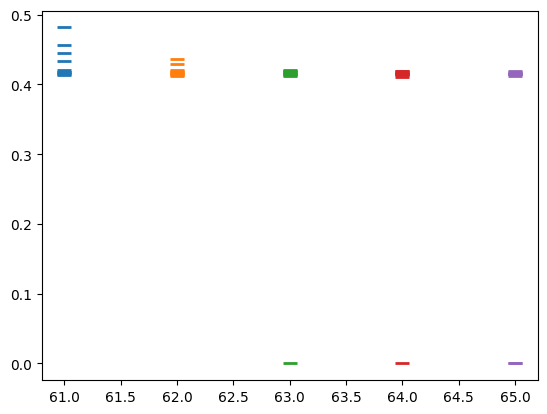

In [184]:
for l in E.keys():
  plt.plot(l+E[l]*0,E[l],label=f"L={l}",marker='_',ls="None",markersize=10, mew=2)

array([3.37700414e-17, 2.73653295e-16, 4.12256485e-01, 4.14641092e-01,
       4.14998783e-01, 4.15340216e-01, 4.15614547e-01, 4.16944673e-01,
       4.18296928e-01, 4.18826282e-01])

In [207]:
statesOccupancy=createFermionicBasis(21,7, L=63)
statesOccupied=convertToOccupiedStates(statesOccupancy)
statesOccupied=sortListOfLists(statesOccupied)
statesOccupancy=None
H=np.zeros((len(statesOccupied),len(statesOccupied)))
for indx,state in enumerate(statesOccupied):
    q=list(state)
    for i in range(len(state)):
      for j in range(i+1, len(state)):
        v2=V2[(state[i],state[j])]
        H[indx,indx]+=v2[(state[i],state[j])]
        for scatteredState in v2.keys():
          if scatteredState[0] in q or (scatteredState[1] in q):
            continue;
          qprime=q[:i]+[scatteredState[0]]+q[i+1:j]+[scatteredState[1]]+q[j+1:]
          sign,qprime=getSign(qprime)
          indexprime=searchSortedList(statesOccupied,qprime)
          if indexprime!=-1:
            H[indx,indexprime]+=sign*v2[scatteredState]
          else:
            print("state not found",qprime)
            print("scattered state",scatteredState)
            print("original state",state)
            print((state[i],state[j]))
  
e,ev= eigsh(csr_matrix(H), k=10, which='SA')
laughlin=ev[:,0]

In [208]:
statesOccupancy=createFermionicBasis(21,7, L=64)
statesOccupied=convertToOccupiedStates(statesOccupancy)
statesOccupied=sortListOfLists(statesOccupied)
statesOccupancy=None
H=np.zeros((len(statesOccupied),len(statesOccupied)))
for indx,state in enumerate(statesOccupied):
    q=list(state)
    for i in range(len(state)):
      for j in range(i+1, len(state)):
        v2=V2[(state[i],state[j])]
        H[indx,indx]+=v2[(state[i],state[j])]
        for scatteredState in v2.keys():
          if scatteredState[0] in q or (scatteredState[1] in q):
            continue;
          qprime=q[:i]+[scatteredState[0]]+q[i+1:j]+[scatteredState[1]]+q[j+1:]
          sign,qprime=getSign(qprime)
          indexprime=searchSortedList(statesOccupied,qprime)
          if indexprime!=-1:
            H[indx,indexprime]+=sign*v2[scatteredState]
          else:
            print("state not found",qprime)
            print("scattered state",scatteredState)
            print("original state",state)
            print((state[i],state[j]))
  
e,ev= eigsh(csr_matrix(H), k=10, which='SA')
laughlinEdge1=ev[:,0]

In [204]:
def plotAngularMomentumDensity(basis,wf, maxL=0):
  density=[
    sum(wf[i]**2 for i in range(len(basis)) if (l in basis[i])) 
    for l in range(maxL)
    ]
  return density

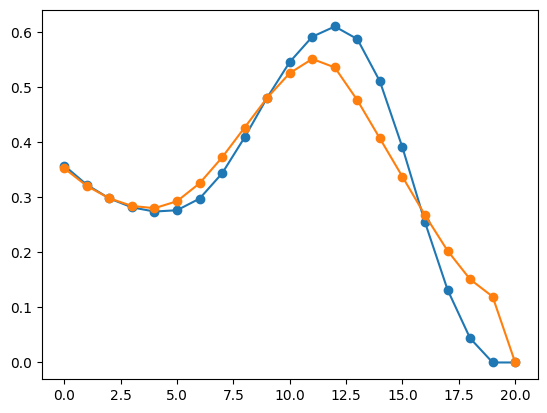

In [210]:
statesOccupancy=createFermionicBasis(21,7, L=63)
statesOccupied=convertToOccupiedStates(statesOccupancy)
statesOccupied=sortListOfLists(statesOccupied)
statesOccupancy=None
plt.plot(plotAngularMomentumDensity(statesOccupied,laughlin, maxL=21),marker='o')

statesOccupancy=createFermionicBasis(21,7, L=64)
statesOccupied=convertToOccupiedStates(statesOccupancy)
statesOccupied=sortListOfLists(statesOccupied)
statesOccupancy=None
plt.plot(plotAngularMomentumDensity(statesOccupied,laughlinEdge1, maxL=21),marker='o')

In [199]:
laughlin

array([ 7.52975565e-18, -1.16121101e-18, -2.99887433e-18, ...,
        1.29201540e-02,  4.65202443e-02, -6.84759455e-02], shape=(3644,))

In [203]:
sum(laughlin[i]**2 for i in range(len(statesOccupied)) if 0 in statesOccupied[i])

np.float64(0.3571883241600952)

In [279]:
def laughlinRatio(zn,zo):
  p=0
  g=0
  for i in range(len(zn)):
    g+=np.abs(zn[i])**2-np.abs(zo[i])**2
    for j in range(i+1, len(zn)):
      p=p+np.log(np.abs((zn[i]-zn[j])/(zo[i]-zo[j])))
  return np.exp(p*6-g/2.0)

In [ ]:
N=20
R=np.sqrt(2*3*N)
z=np.sqrt(np.random.uniform(0,R**2, size=N))*np.exp(1j*np.random.uniform(0,2*np.pi, size=N))
zs=[]

zbins=np.linspace(0,R*1.2, 100)
density=np.zeros(len(zbins)-1)
binsize=zbins[1]-zbins[0]
iters=100000
for i in range(iters):
  dz=np.random.uniform(-1,1, size=N)*np.exp(1j*np.random.uniform(0,2*np.pi, size=N))
  zn=z+dz
  ratio=laughlinRatio(zn,z)
  if ratio>1 or np.random.uniform(0,1)<ratio:
    z=zn
  if i>10000:
    density+=np.histogram(np.abs(z), bins=zbins)[0]
density=density/binsize/(zbins[:-1]+binsize/2)/(iters-10000)

/tmp/ipykernel_3519647/3690150571.py:6: RuntimeWarning: overflow encountered in scalar multiply
  p=p*(z[i]-z[j])**3
/tmp/ipykernel_3519647/3690150571.py:6: RuntimeWarning: invalid value encountered in scalar multiply
  p=p*(z[i]-z[j])**3


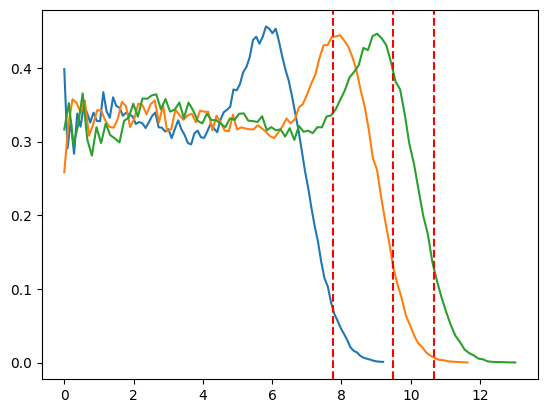

In [294]:

densities={10:density10, 16:density16, 20:density20}
for N in densities.keys():
  R=np.sqrt(2*3*N)
  zbins=np.linspace(0,R*1.2, 100)
  plt.plot(zbins[:-1],densities[N])
plt.axvline(np.sqrt(2*3*(20-1)), color='r', linestyle='--', label='Droplet Radius')
plt.axvline(np.sqrt(2*3*(16-1)), color='r', linestyle='--', label='Droplet Radius')
plt.axvline(np.sqrt(2*3*(10)), color='r', linestyle='--', label='Droplet Radius')